In [21]:
import time
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.datasets import make_classification, make_moons, make_blobs
from sklearn.metrics import accuracy_score, roc_curve, auc, ConfusionMatrixDisplay, confusion_matrix

# Data Generation

In [59]:
X ,y = make_blobs(n_samples=2502, 
                  random_state=259202, 
                  n_features=2, 
                  centers=7, 
                  cluster_std=0.8)

In [60]:
X.shape, y.shape

((2502, 2), (2502,))

In [61]:
y = np.where(y < 3, 0, 1)

In [62]:
def plot_data(X, y, title=""):
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=X[:,0], y=X[:,1], hue=y)
    plt.title(title)
    plt.show()

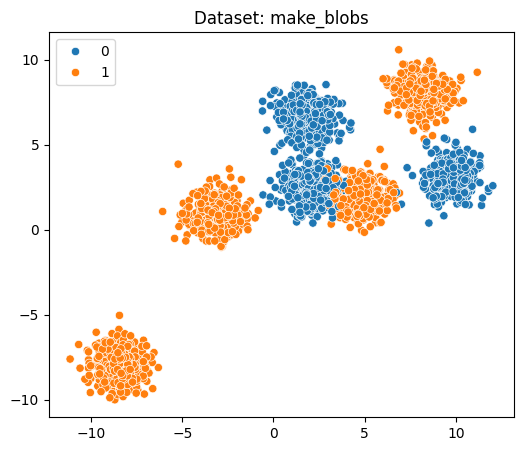

In [63]:
plot_data(X,y,"Dataset: make_blobs")

In [64]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=259202)

In [65]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((1876, 2), (1876,), (626, 2), (626,))

In [66]:
def plot_decision_boundary(X, y, model, title=""):
    h = 0.05
    x_min, x_max = X[:,0].min() - 1, X[:,0].max() + 1
    y_min, y_max = X[:,1].min() - 1, X[:,1].max() + 1
    xx, yy = np.meshgrid(
        np.arange(x_min, x_max, h),
        np.arange(y_min, y_max, h)
    )
    pts = np.c_[xx.ravel(), yy.ravel()]

    Z = model.predict(pts)

    Z = Z.reshape(xx.shape)

    # decition boundary
    plt.contourf(xx, yy, Z, alpha=0.3)

    # decision line
    plt.contour(xx, yy, Z, colors='k', linewidths=1)

    scatter = plt.scatter(X[:,0], X[:,1], c=y, edgecolors='k')

    plt.legend(*scatter.legend_elements(), loc="upper right", title="Classes")
    plt.title(title)
    plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
    plt.show()

# Neural network

In [67]:
class NeuralNetwork(BaseEstimator, ClassifierMixin):
    def __init__(self, layers=[2, 10, 2], lr = 0.01, epochs = 100, epsilon=1e-5, batch_size = None):
        self.layers = layers
        self.lr = lr
        self.epochs = epochs
        self.epsilon = epsilon
        self.batch_size = batch_size
        self.W = []
        self.b = []
        for i in range(len(layers) - 1):
            self.W.append(np.random.randn(layers[i], layers[i+1]) * np.sqrt(2/layers[i]))
            self.b.append(np.zeros((1, layers[i+1]))) 
            
    def relu(self, x):
        return np.maximum(0, x)
    
    def relu_derivative(self, x):
        return (x > 0 ).astype(float)
    
    def softmax(self, x):
        exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
        return exp_x / np.sum(exp_x, axis=1, keepdims=True)
    
    def forward(self, X):
        self.cache = []
        a = X # input layer
        for i in range(len(self.W)):
            s = a @ self.W[i] + self.b[i]
            self.cache.append({'a': a, 's': s})
            if i < len(self.W) - 1:
                a = self.relu(s)
            else:
                a = self.softmax(s)
        return a
    
    def backward(self, y_true, output):
        grads_W = [None]*len(self.W)
        grads_b = [None]*len(self.W)
        grad = output - y_true
        
        for i in reversed(range(len(self.W))):
            a_prev = self.cache[i]['a']
            s = self.cache[i]['s']
            
            if i == len(self.W) - 1:
                ds = grad
            else:
                ds = grad * self.relu_derivative(s)
                
            grads_W[i] = a_prev.T @ ds / a_prev.shape[0]
            grads_b[i] = np.sum(ds, axis=0, keepdims=True) / a_prev.shape[0]
            
            if i > 0:
                grad = ds @ self.W[i].T
                
        return grads_W, grads_b
    
    def update(self, grads_W, grads_b):
        for i in range(len(self.W)):
            self.W[i] -= self.lr * grads_W[i]
            self.b[i] -= self.lr * grads_b[i]
    
    def fit(self, X, y):
        num_classes = len(np.unique(y))
        y_onehot = np.eye(num_classes)[y]
        prev_loss = None
        n_samples = X.shape[0]
        batch_size = self.batch_size if self.batch_size is not None else n_samples 
        
        for epoch in range(self.epochs):
            indices = np.arange(n_samples)
            np.random.shuffle(indices)
            X_shuffled = X[indices]
            y_onehot_shuffled = y_onehot[indices]
            
            for start in range(0, n_samples, batch_size):
                end = start + batch_size
                X_batch = X_shuffled[start:end]
                y_batch = y_onehot_shuffled[start:end]

                out = self.forward(X_batch)
                grads_W, grads_b = self.backward(y_batch, out)
                self.update(grads_W, grads_b)
            
            out_ = self.forward(X)
            loss = -np.mean(np.sum(y_onehot * np.log(out_ + 1e-8), axis=1))
            if epoch % 20 == 0:
                print(f"Epoch {epoch} - Loss: {loss}")
            if prev_loss is not None and abs(prev_loss - loss) < self.epsilon:
                print(f"Loss diff < epsilon at epoch {epoch} - Loss {loss}")
                break
            prev_loss = loss
    
    def predict(self, X):
        out = self.forward(X)
        return np.argmax(out, axis=1) # index of the largest value in each row
    
    def score(self, X, y):
        y_pred = self.predict(X)
        return np.mean(y_pred == y)

In [76]:
nn = NeuralNetwork([X_train.shape[1], 10, 10, 2], lr = 0.05, epochs=500, batch_size=256)
nn.fit(X_train, y_train)
y_pred = nn.predict(X_test)
acc = np.mean(y_pred == y_test)
print(f"Accuracy: {acc}")

Epoch 0 - Loss: 0.38677671999589197
Epoch 20 - Loss: 0.2823677872256252
Epoch 40 - Loss: 0.24459689319713163
Epoch 60 - Loss: 0.2612725619360606
Epoch 80 - Loss: 0.17722142620067183
Epoch 100 - Loss: 0.1124968342860325
Epoch 120 - Loss: 0.08661181643067159
Epoch 140 - Loss: 0.1083692056540166
Epoch 160 - Loss: 0.06165573872171891
Epoch 180 - Loss: 0.05914937309199698
Epoch 200 - Loss: 0.05054369286266923
Epoch 220 - Loss: 0.048290540187485874
Epoch 240 - Loss: 0.046494086054293025
Epoch 260 - Loss: 0.06561903095881502
Epoch 280 - Loss: 0.05944285862982732
Epoch 300 - Loss: 0.05211445709693027
Epoch 320 - Loss: 0.08688012935189235
Epoch 340 - Loss: 0.04594707038817274
Loss diff < epsilon at epoch 359 - Loss 0.04325794767829236
Accuracy: 0.9856230031948882


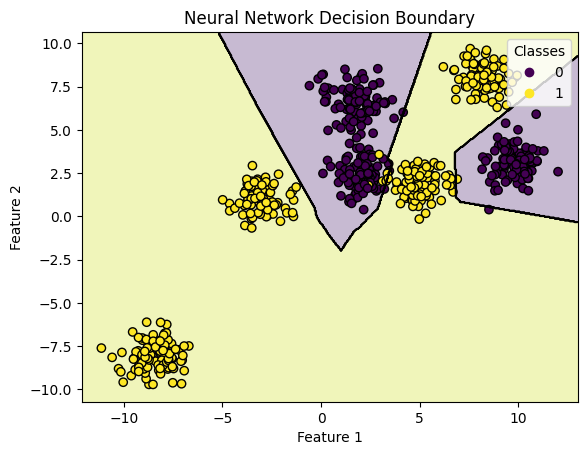

In [77]:
plot_decision_boundary(X_test, y_test, nn, title="Neural Network Decision Boundary")

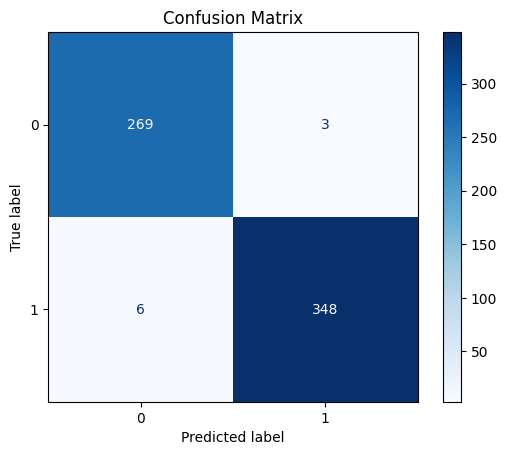

In [78]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [79]:
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn+fp) # swoisciwość
sensitivity = tp / (tp+fn) # czułość
print(f"Specificity: {specificity}\nSensitivity: {sensitivity}")

Specificity: 0.9889705882352942
Sensitivity: 0.9830508474576272


In [201]:
parameters = {
    'layers': [[X_train.shape[1], 10, 10, 2], [X_train.shape[1], 10, 20, 10, 2], [X_train.shape[1], 20, 20, 2], [X_train.shape[1], 30, 40, 30, 2]],
    'epochs': [200, 500, 1000],
    'lr': [0.1, 0.05, 0.01, 0.001],
}

clf = NeuralNetwork()
grid_search = GridSearchCV(clf, parameters, cv=3, n_jobs=-1, verbose=5)
grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Epoch 0 - Loss: 6.2950839335210835
Epoch 50 - Loss: 0.28990167256762345
Epoch 100 - Loss: 0.26227749354455626
Epoch 150 - Loss: 0.23303395147369899
Epoch 200 - Loss: 0.21032187741396685
Epoch 250 - Loss: 0.17636570380781683
Epoch 300 - Loss: 0.15494435211188848
Epoch 350 - Loss: 0.14042525672490863
Epoch 400 - Loss: 0.12806985795723075
Epoch 450 - Loss: 0.11606858461052895
Epoch 500 - Loss: 0.10644899096763945
Epoch 550 - Loss: 0.09928519080595886
Epoch 600 - Loss: 0.09274700759347464
Epoch 650 - Loss: 0.08758902632641685
Epoch 700 - Loss: 0.0833742857784922
Epoch 750 - Loss: 0.08022300206016848
Epoch 800 - Loss: 0.07759987256104736
Epoch 850 - Loss: 0.07537399632368574
Epoch 900 - Loss: 0.07349071280043808
Epoch 950 - Loss: 0.07187080774542971


GridSearchCV(cv=3, estimator=NeuralNetwork(), n_jobs=-1,
             param_grid={'epochs': [200, 500, 1000],
                         'layers': [[2, 10, 10, 2], [2, 10, 20, 10, 2],
                                    [2, 20, 20, 2], [2, 30, 40, 30, 2]],
                         'lr': [0.1, 0.05, 0.01, 0.001]},
             verbose=5)

In [202]:
grid_search_df = pd.DataFrame(grid_search.cv_results_)
grid_search_df.sort_values(by=['rank_test_score'])[:5]

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_epochs,param_layers,param_lr,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
32,0.751108,0.017411,0.001000,8.778064e-07,1000,"[2, 10, 10, 2]",0.1,"{'epochs': 1000, 'layers': [2, 10, 10, 2], 'lr...",0.985623,0.9680,0.9888,0.980808,0.009149,1
44,0.656948,0.031285,0.000504,7.126751e-04,1000,"[2, 30, 40, 30, 2]",0.1,"{'epochs': 1000, 'layers': [2, 30, 40, 30, 2],...",0.985623,0.9584,0.9888,0.977608,0.013644,2
40,0.733355,0.069163,0.000666,4.711470e-04,1000,"[2, 20, 20, 2]",0.1,"{'epochs': 1000, 'layers': [2, 20, 20, 2], 'lr...",0.987220,0.9632,0.9808,0.977073,0.010154,3
37,0.722532,0.070003,0.000666,4.712580e-04,1000,"[2, 10, 20, 10, 2]",0.05,"{'epochs': 1000, 'layers': [2, 10, 20, 10, 2],...",0.980831,0.9648,0.9776,0.974410,0.006922,4
41,0.768762,0.102877,0.000337,4.771023e-04,1000,"[2, 20, 20, 2]",0.05,"{'epochs': 1000, 'layers': [2, 20, 20, 2], 'lr...",0.972843,0.9584,0.9840,0.971748,0.010480,5


# MNIST

In [86]:
train, test = pd.read_csv('./dataset/mnist_train.csv'), pd.read_csv('./dataset/mnist_test.csv')
train

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59995,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59996,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59997,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
59998,6,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [87]:
X_train, y_train = train.drop(columns=['label']), train['label']
X_test, y_test = test.drop(columns=['label']), test['label']
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((60000, 784), (60000,), (10000, 784), (10000,))

In [88]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [89]:
y_train.unique()

array([5, 0, 4, 1, 9, 2, 3, 6, 7, 8], dtype=int64)

In [91]:
nn = NeuralNetwork([784, 256, 10], lr = 0.005, epochs = 100, batch_size = 128)
nn.fit(X_train, y_train.values)
y_pred = nn.predict(X_test)
print(f"Mnist acc: {np.mean(y_pred == y_test)}")

Epoch 0 - Loss: 0.9511753655135411
Epoch 20 - Loss: 0.26970336859914584
Epoch 40 - Loss: 0.21177969798112908
Epoch 60 - Loss: 0.1759691982399666
Epoch 80 - Loss: 0.15030102147809976
Mnist acc: 0.9586


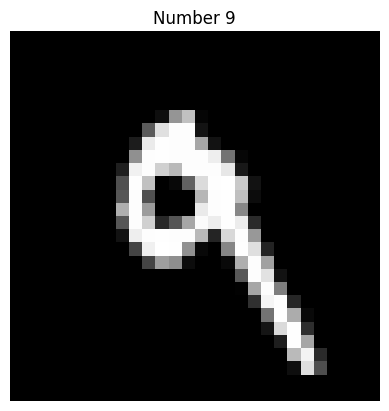

Predicted by the neural network: [9]


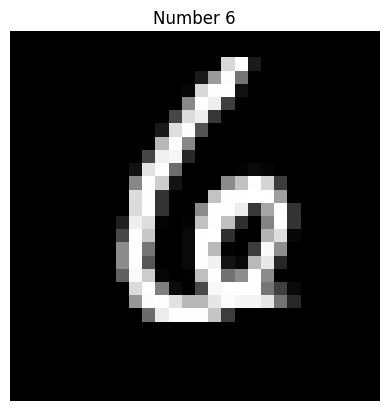

Predicted by the neural network: [6]


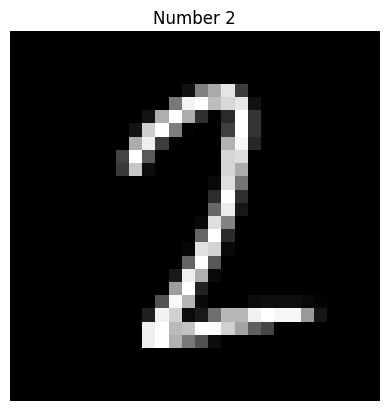

Predicted by the neural network: [2]


In [98]:
for i in [7, 123, 456]:
    plt.imshow(X_test[i].reshape(28,28), cmap='gray')
    plt.title(f"Number {y_test[i]}")
    plt.axis('off')
    plt.show()
    print(f"Predicted by the neural network: {nn.predict(X_test[i])}")